In [54]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_blobs

In [60]:
centroid = [(-5,-5), (5,5)]
cluster_std = [1,1]

X,y = make_blobs(n_samples=100, centers=centroid, cluster_std=cluster_std, n_features=2, random_state=42)

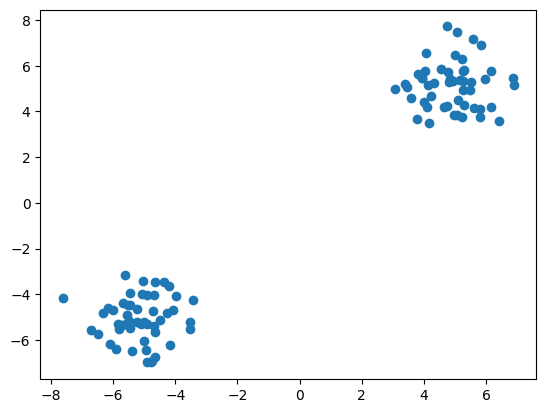

In [61]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0],X[:,1])
plt.show()

# create Kmean class


In [133]:
# import random
# class KMeans:
#   def __init__(self, n_clusters=2, max_iter=100,random_state=42):
#     self.n_clusters = n_clusters
#     self.max_iter = max_iter
#     self.random_state = random_state
#     self.centroids = None


#   def fit(self, X):
#     # print(X)
#     # choose centroids
#     # print(random.sample(range(0,X.shape[0]), self.n_clusters))
#     random_index = random.sample(range(0,X.shape[0]), self.n_clusters)
#     self.centroids = X[random_index]
#     # print(self.centroids)

#     # cluster_groups = self.assign_clusters(X)
#     # print(cluster_groups.shape)



#     for i in range(self.max_iter):
#       # assign clusters
#       cluster_groups = self.assign_clusters(X)
#       # move centroids
#       old_centroids = self.centroids
#       self_centroids = self.move_centroids(X, cluster_groups)

#       # check finish

#       if (old_centroids == self.centroids).all():
#         break
#     return cluster_groups

#   def assign_clusters(self, X):
#     cluster_groups = []
#     distances = []

#     for row in X:
#       for centroid in self.centroids:
#         distances.append(np.sqrt(np.dot(row-centroid, row-centroid)))
#       min_distance = min(distances)
#       index_pos = distances.index(min_distance)
#       cluster_groups.append(index_pos)



#       # print(index_pos)

#       # print(distances)
#       distances.clear()

#     return np.array(cluster_groups)


# def move_centroids(self, X, cluster_groups):
#   new_centroid = []
#   cluster_types = np.unique(cluster_groups)

#   for type in cluster_types:
#     new_centroid.append(X[cluster_groups == type].mean(axis=0))
#   return np.array(new_centroid)

In [135]:
import random
import numpy as np

class KMeans:
  def __init__(self, n_clusters=2, max_iter=100,random_state=42):
    self.n_clusters = n_clusters
    self.max_iter = max_iter
    self.random_state = random_state
    self.centroids = None


  def fit(self, X):
    # print(X)
    # choose centroids
    # print(random.sample(range(0,X.shape[0]), self.n_clusters))
    random_index = random.sample(range(0,X.shape[0]), self.n_clusters)
    self.centroids = X[random_index]
    # print(self.centroids)

    # cluster_groups = self.assign_clusters(X)
    # print(cluster_groups.shape)

    for i in range(self.max_iter):
      # assign clusters
      cluster_groups = self.assign_clusters(X)
      # move centroids
      old_centroids = self.centroids
      self.centroids = self.move_centroids(X, cluster_groups) # Fixed: self_centroids -> self.centroids

      # check finish

      if (old_centroids == self.centroids).all():
        break
    return cluster_groups

  def assign_clusters(self, X):
    cluster_groups = []
    distances = []

    for row in X:
      for centroid in self.centroids:
        distances.append(np.sqrt(np.dot(row-centroid, row-centroid)))
      min_distance = min(distances)
      index_pos = distances.index(min_distance)
      cluster_groups.append(index_pos)

      # print(index_pos)

      # print(distances)
      distances.clear()

    return np.array(cluster_groups)

  # Fixed: Indentation sahi kar ke class ke andar include kar diya
  def move_centroids(self, X, cluster_groups):
    new_centroid = []
    cluster_types = np.unique(cluster_groups)

    for type in cluster_types:
      new_centroid.append(X[cluster_groups == type].mean(axis=0))
    return np.array(new_centroid)

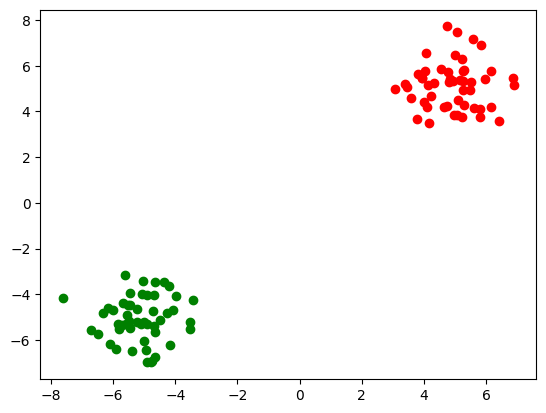

In [136]:
km = KMeans(n_clusters=2, max_iter=100)
y_means = km.fit(X)

plt.scatter(X[y_means==0,0],X[y_means==0,1], color='red')
plt.scatter(X[y_means==1,0],X[y_means==1,1], color='green')
plt.show()

# choose centroids


In [1]:
from sklearn.cluster import KMeans

# Ideal production setup
km = KMeans(
    n_clusters=3,        # 3 groups mein divide karo
    init='k-means++',     # Smart centroid initialization
    n_init=10,            # Best result chunne ke liye 10 baar run karo
    max_iter=300,         # Max 300 iterations tak chalo
    random_state=42       # Fixed randomness
)

km.fit(X)

NameError: name 'X' is not defined